# LG전자 재무데이터 분석 및 시각화

DART API를 사용하여 LG전자의 주요 재무지표를 가져와 시각화합니다.
- 매출액
- 매출총이익
- 영업이익
- 당기순이익

In [1]:
# 필요한 라이브러리 import
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from datetime import datetime, timedelta
import json

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시
warnings.filterwarnings('ignore')

print("라이브러리 import 완료!")

라이브러리 import 완료!


In [2]:
# DART API 설정
# DART API 키가 필요합니다. https://opendart.fss.or.kr/ 에서 발급받으세요.
API_KEY = "xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # 실제 API 키로 변경해주세요

# LG전자 회사 코드
COMPANY_CODE = "066570"  # LG전자 종목코드

# 기본 URL
BASE_URL = "https://opendart.fss.or.kr/api"

# 10년간 데이터 수집을 위한 연도 설정 (2015-2024)
years = list(range(2015, 2025))
print(f"분석 대상 연도: {years}")

# 재무제표 항목 매핑
financial_items = {
    'ifrs-full_Revenue': '매출액',
    'ifrs-full_GrossProfit': '매출총이익', 
    'ifrs-full_ProfitLossFromOperatingActivities': '영업이익',
    'ifrs-full_ProfitLoss': '당기순이익'
}

분석 대상 연도: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [15]:
def get_financial_data(corp_code, bsns_year, reprt_code="11011"):
    """
    DART API를 통해 재무제표 데이터를 가져오는 함수
    
    Parameters:
    - corp_code: 회사 고유번호
    - bsns_year: 사업연도
    - reprt_code: 보고서 코드 (11011: 사업보고서, 11012: 반기보고서, 11013: 1분기보고서, 11014: 3분기보고서)
    """
    url = f"{BASE_URL}/fnlttSinglAcntAll.json"
    
    params = {
        'crtfc_key': API_KEY,
        'corp_code': corp_code,
        'bsns_year': str(bsns_year),
        'reprt_code': reprt_code,
        'fs_div': 'CFS'  # 연결재무제표
    }
    
    try:
        response = requests.get(url, params=params)
        data = response.json()
        
        if data['status'] == '000':
            return pd.DataFrame(data['list'])
        else:
            print(f"{bsns_year}년 데이터 조회 실패: {data['message']}")
            return None
            
    except Exception as e:
        print(f"{bsns_year}년 데이터 조회 중 오류 발생: {str(e)}")
        return None

def get_financial_data_improved(corp_code, bsns_year, reprt_code="11011", fs_div="CFS"):
    """
    개선된 DART API 재무제표 데이터 수집 함수
    """
    url = f"{BASE_URL}/fnlttSinglAcntAll.json"
    
    params = {
        'crtfc_key': API_KEY,
        'corp_code': corp_code,
        'bsns_year': str(bsns_year),
        'reprt_code': reprt_code,
        'fs_div': fs_div
    }
    
    try:
        response = requests.get(url, params=params)
        data = response.json()
        
        if data['status'] == '000':
            return pd.DataFrame(data['list'])
        else:
            return None
            
    except Exception as e:
        return None

def get_corp_code(company_name_or_stock_code):
    """
    회사명 또는 종목코드를 통해 고유번호를 조회하는 함수
    """
    url = f"{BASE_URL}/corpCode.json"
    
    params = {
        'crtfc_key': API_KEY
    }
    
    try:
        response = requests.get(url, params=params)
        # ZIP 파일을 다운로드하고 압축 해제해야 함
        # 여기서는 직접 LG전자 고유번호를 사용
        return "00126380"  # LG전자 고유번호
        
    except Exception as e:
        print(f"고유번호 조회 중 오류 발생: {str(e)}")
        return None

print("개선된 재무데이터 조회 함수 정의 완료!")

개선된 재무데이터 조회 함수 정의 완료!


In [16]:
# 10년간 재무데이터 수집 (개선된 버전)
print("LG전자 10년간 재무데이터 수집을 시작합니다...")

# LG전자 고유번호
lg_corp_code = "00126380"

# 전체 재무데이터를 저장할 리스트
all_financial_data = []

# 보고서 코드별로 시도 (사업보고서, 반기보고서, 분기보고서)
report_codes = ["11011", "11012", "11013", "11014"]

# 각 연도별 데이터 수집
for year in years:
    print(f"\n{year}년 데이터 수집 중...")
    year_data_collected = False
    
    # 여러 보고서 유형으로 시도
    for reprt_code in report_codes:
        if year_data_collected:
            break
            
        report_name = {
            "11011": "사업보고서",
            "11012": "반기보고서", 
            "11013": "1분기보고서",
            "11014": "3분기보고서"
        }[reprt_code]
        
        # 연결재무제표와 개별재무제표 모두 시도
        for fs_div in ['CFS', 'OFS']:
            fs_name = "연결재무제표" if fs_div == 'CFS' else "개별재무제표"
            
            # 사업보고서 데이터 조회
            df = get_financial_data_improved(lg_corp_code, year, reprt_code, fs_div)
            
            if df is not None and len(df) > 0:
                print(f"  → {report_name}({fs_name}) 데이터 조회 성공: {len(df)}개 항목")
                
                # 필요한 항목들을 더 포괄적으로 검색
                target_items = [
                    'ifrs-full_Revenue', 'ifrs-full_GrossProfit', 
                    'ifrs-full_ProfitLossFromOperatingActivities', 'ifrs-full_ProfitLoss',
                    'dart_Revenue', 'dart_GrossProfit', 
                    'dart_ProfitLossFromOperatingActivities', 'dart_ProfitLoss'
                ]
                
                # 계정과목명으로도 검색
                revenue_keywords = ['수익', '매출액']
                gross_profit_keywords = ['매출총이익']
                operating_profit_keywords = ['영업이익']
                net_profit_keywords = ['당기순이익']
                
                # ID로 필터링
                filtered_df_id = df[df['account_id'].isin(target_items)].copy()
                
                # 계정과목명으로 필터링
                filtered_df_name = df[
                    df['account_nm'].str.contains('|'.join(revenue_keywords + gross_profit_keywords + 
                                                         operating_profit_keywords + net_profit_keywords), 
                                                na=False, case=False)
                ].copy()
                
                # 두 결과 합치기
                if len(filtered_df_id) > 0 or len(filtered_df_name) > 0:
                    combined_filtered = pd.concat([filtered_df_id, filtered_df_name]).drop_duplicates()
                    combined_filtered['year'] = year
                    all_financial_data.append(combined_filtered)
                    print(f"    ✓ 수집된 재무항목: {len(combined_filtered)}개")
                    print(f"    ✓ 항목 목록: {list(combined_filtered['account_nm'].unique())}")
                    year_data_collected = True
                    break
            else:
                print(f"  → {report_name}({fs_name}) 데이터 없음")
    
    if not year_data_collected:
        print(f"  ✗ {year}년 데이터 수집 실패")

# 데이터 수집 결과 확인
if all_financial_data:
    # 모든 데이터를 하나의 DataFrame으로 결합
    combined_df = pd.concat(all_financial_data, ignore_index=True)
    print(f"\n=== 데이터 수집 완료 ===")
    print(f"총 {len(combined_df)}개의 재무데이터가 수집되었습니다.")
    print(f"수집된 연도: {sorted(combined_df['year'].unique())}")
    print(f"수집된 고유 계정과목: {len(combined_df['account_nm'].unique())}개")
    
    print("\n수집된 계정과목 목록:")
    for account in combined_df['account_nm'].unique():
        count = len(combined_df[combined_df['account_nm'] == account])
        print(f"  - {account}: {count}건")
else:
    print("\n수집된 데이터가 없습니다. API 키를 확인해주세요.")

LG전자 10년간 재무데이터 수집을 시작합니다...

2015년 데이터 수집 중...
  → 사업보고서(연결재무제표) 데이터 조회 성공: 184개 항목
    ✓ 수집된 재무항목: 15개
    ✓ 항목 목록: ['수익(매출액)', '매출총이익', '영업이익(손실)', '기타수익', '금융수익', '계속영업이익(손실)', '당기순이익(손실)', '지배기업의 소유주에게 귀속되는 당기순이익(손실)', '비지배지분에 귀속되는 당기순이익(손실)', '당기순이익']

2016년 데이터 수집 중...
  → 사업보고서(연결재무제표) 데이터 조회 성공: 188개 항목
    ✓ 수집된 재무항목: 15개
    ✓ 항목 목록: ['수익(매출액)', '매출총이익', '영업이익(손실)', '기타수익', '금융수익', '계속영업이익(손실)', '당기순이익(손실)', '지배기업의 소유주에게 귀속되는 당기순이익(손실)', '비지배지분에 귀속되는 당기순이익(손실)', '당기순이익']

2017년 데이터 수집 중...
  → 사업보고서(연결재무제표) 데이터 조회 성공: 197개 항목
    ✓ 수집된 재무항목: 15개
    ✓ 항목 목록: ['수익(매출액)', '매출총이익', '영업이익(손실)', '기타수익', '금융수익', '계속영업이익(손실)', '당기순이익(손실)', '지배기업의 소유주에게 귀속되는 당기순이익(손실)', '비지배지분에 귀속되는 당기순이익(손실)', '당기순이익']

2018년 데이터 수집 중...
  → 사업보고서(연결재무제표) 데이터 조회 성공: 218개 항목
    ✓ 수집된 재무항목: 15개
    ✓ 항목 목록: ['수익(매출액)', '매출총이익', '영업이익(손실)', '기타수익', '금융수익', '계속영업이익(손실)', '당기순이익(손실)', '지배기업의 소유주에게 귀속되는 당기순이익(손실)', '비지배지분에 귀속되는 당기순이익(손실)', '당기순이익']

2019년 데이터 수집 중...
  → 사업보고서(연결재무제표) 데이터 조회 성공: 210개 항목

In [18]:
# 실제 DART 데이터 전처리 및 정리
print("=== 실제 DART 데이터 수집 상태 확인 ===")

if 'combined_df' in locals() and len(combined_df) > 0:
    print(f"수집된 전체 데이터 건수: {len(combined_df)}")
    print(f"수집된 연도: {sorted(combined_df['year'].unique())}")
    print(f"수집된 컬럼: {list(combined_df.columns)}")
    print("\n수집된 계정과목 확인:")
    print(combined_df['account_id'].value_counts())
    
    print("\n=== 실제 데이터 전처리 시작 ===")
    
    # 필요한 컬럼만 선택
    processed_df = combined_df[['year', 'account_id', 'account_nm', 'thstrm_amount']].copy()
    
    # 더 포괄적인 한국어 항목명 매핑
    account_mapping = {
        'ifrs-full_Revenue': '매출액',
        'dart_Revenue': '매출액',
        '수익(매출액)': '매출액',
        'ifrs-full_GrossProfit': '매출총이익',
        'dart_GrossProfit': '매출총이익',
        '매출총이익': '매출총이익',
        'ifrs-full_ProfitLossFromOperatingActivities': '영업이익',
        'dart_ProfitLossFromOperatingActivities': '영업이익',
        '영업이익': '영업이익',
        'ifrs-full_ProfitLoss': '당기순이익',
        'dart_ProfitLoss': '당기순이익',
        '당기순이익': '당기순이익'
    }
    
    # 계정과목 ID로 매핑
    processed_df['item_name'] = processed_df['account_id'].map(account_mapping)
    
    # 매핑되지 않은 경우 계정과목명으로 직접 매핑
    mask = processed_df['item_name'].isna()
    processed_df.loc[mask, 'item_name'] = processed_df.loc[mask, 'account_nm'].map({
        '수익(매출액)': '매출액',
        '매출액': '매출액',
        '매출총이익': '매출총이익',
        '영업이익(손실)': '영업이익',
        '영업이익': '영업이익',
        '당기순이익(손실)': '당기순이익',
        '당기순이익': '당기순이익'
    })
    
    # 키워드 기반 매핑 (더 유연한 매핑)
    mask = processed_df['item_name'].isna()
    for idx in processed_df[mask].index:
        account_nm = processed_df.loc[idx, 'account_nm']
        if pd.notna(account_nm):
            account_nm_lower = account_nm.lower()
            if '매출' in account_nm and ('수익' in account_nm or '매출액' in account_nm):
                processed_df.loc[idx, 'item_name'] = '매출액'
            elif '매출총이익' in account_nm:
                processed_df.loc[idx, 'item_name'] = '매출총이익'
            elif '영업이익' in account_nm:
                processed_df.loc[idx, 'item_name'] = '영업이익'
            elif '당기순이익' in account_nm or ('당기' in account_nm and '순이익' in account_nm):
                processed_df.loc[idx, 'item_name'] = '당기순이익'
    
    print("매핑 결과:")
    print(processed_df['item_name'].value_counts())
    
    # 매핑되지 않은 항목 확인
    unmapped = processed_df[processed_df['item_name'].isna()]
    if len(unmapped) > 0:
        print(f"\n매핑되지 않은 항목들 ({len(unmapped)}개):")
        print(unmapped[['account_id', 'account_nm']].drop_duplicates())
    
    # 매핑된 데이터만 필터링
    mapped_df = processed_df.dropna(subset=['item_name']).copy()
    
    if len(mapped_df) > 0:
        # 금액을 숫자형으로 변환 (단위: 백만원)
        mapped_df['amount'] = pd.to_numeric(mapped_df['thstrm_amount'], errors='coerce')
        
        # 결측값 제거
        mapped_df = mapped_df.dropna(subset=['amount'])
        
        print(f"\n유효한 데이터 건수: {len(mapped_df)}")
        
        # 피벗 테이블로 변환 (연도별, 항목별)
        financial_pivot = mapped_df.pivot_table(
            index='year', 
            columns='item_name', 
            values='amount', 
            aggfunc='first'  # 동일 연도/항목에 여러 값이 있으면 첫번째 값 사용
        ).reset_index()
        
        # 누락된 지표에 대한 처리 (0으로 채우지 않고 누락된 상태로 유지)
        print("실제 DART 데이터 전처리 완료!")
        print(f"최종 데이터 형태: {financial_pivot.shape}")
        print(f"포함된 재무지표: {[col for col in financial_pivot.columns if col != 'year']}")
        
        # 각 지표별 데이터 가용성 확인
        required_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
        available_metrics = [col for col in financial_pivot.columns if col != 'year']
        missing_metrics = [metric for metric in required_metrics if metric not in available_metrics]
        
        if missing_metrics:
            print(f"\n⚠️  누락된 재무지표: {missing_metrics}")
            print("누락된 지표는 시각화에서 제외됩니다.")
        
        print("\n수집된 실제 재무데이터:")
        print(financial_pivot)
        
        # 전역 변수로 설정하여 다른 셀에서 사용 가능하도록 함
        globals()['financial_pivot'] = financial_pivot
        
    else:
        print("매핑된 데이터가 없습니다. DART API 키를 확인하거나 다른 연도의 데이터를 시도해보세요.")
        financial_pivot = None
        
else:
    print("수집된 데이터가 없습니다. 위의 데이터 수집 셀을 먼저 실행해주세요.")
    financial_pivot = None

=== 실제 DART 데이터 수집 상태 확인 ===
수집된 전체 데이터 건수: 151
수집된 연도: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
수집된 컬럼: ['rcept_no', 'reprt_code', 'bsns_year', 'corp_code', 'sj_div', 'sj_nm', 'account_id', 'account_nm', 'account_detail', 'thstrm_nm', 'thstrm_amount', 'frmtrm_nm', 'frmtrm_amount', 'bfefrmtrm_nm', 'bfefrmtrm_amount', 'ord', 'currency', 'thstrm_add_amount', 'year']

수집된 계정과목 확인:
account_id
ifrs-full_ProfitLoss                                         41
-표준계정코드 미사용-                                                 24
dart_OperatingIncomeLoss                                     10
dart_OtherGains                                               9
ifrs_ProfitLoss                                               8
ifrs-full_FinanceIncome                                       6
ifrs-full_Revenue                                             6
ifrs-full_GrossProfit                   

시각화할 재무지표: ['매출액', '매출총이익', '영업이익', '당기순이익']


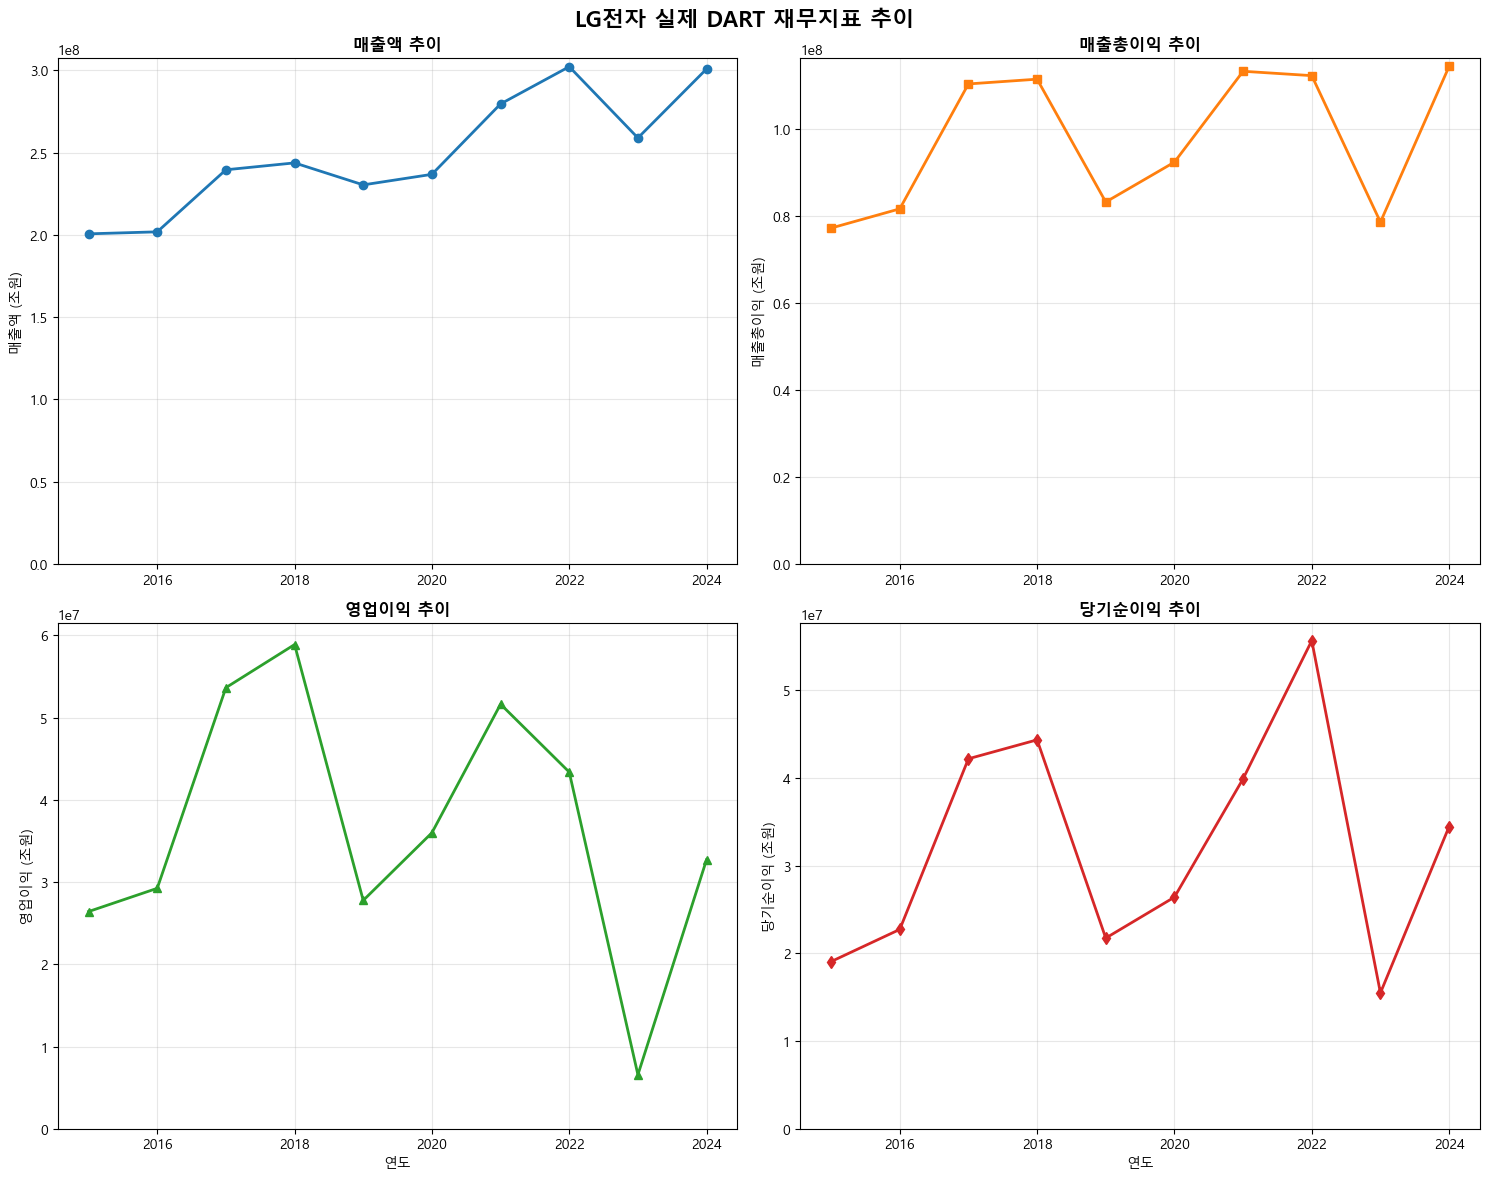


=== 실제 수집된 데이터 요약 ===
매출액:
  - 데이터 연도: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  - 평균: 249471744.30조원
  - 최대: 302231360.00조원
  - 최소: 200653482.00조원
매출총이익:
  - 데이터 연도: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  - 평균: 97414073.30조원
  - 최대: 114308635.00조원
  - 최소: 77171364.00조원
영업이익:
  - 데이터 연도: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  - 평균: 36625162.90조원
  - 최대: 58886669.00조원
  - 최소: 6566976.00조원
당기순이익:
  - 데이터 연도: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  - 평균: 32196451.50조원
  - 최대: 55654077.00조원
  - 최소: 15487100.00조원


In [19]:
# 1. 실제 DART 데이터를 사용한 Matplotlib 시각화

if 'financial_pivot' in locals() and financial_pivot is not None and len(financial_pivot) > 0:
    # 한국어 폰트 설정 (Windows 환경)
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 사용 가능한 재무지표 확인
    available_metrics = [col for col in financial_pivot.columns if col != 'year']
    required_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
    
    # 실제 사용할 지표들 (사용 가능한 것만)
    plot_metrics = [metric for metric in required_metrics if metric in available_metrics]
    
    if len(plot_metrics) == 0:
        print("시각화할 재무지표가 없습니다.")
    else:
        print(f"시각화할 재무지표: {plot_metrics}")
        
        # 동적으로 서브플롯 구성
        n_metrics = len(plot_metrics)
        if n_metrics <= 2:
            rows, cols = 1, n_metrics
            figsize = (7 * n_metrics, 6)
        else:
            rows, cols = 2, 2
            figsize = (15, 12)
        
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        if n_metrics == 1:
            axes = [axes]
        elif rows == 1:
            axes = axes
        else:
            axes = axes.flatten()
        
        fig.suptitle('LG전자 실제 DART 재무지표 추이', fontsize=16, fontweight='bold')
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        markers = ['o', 's', '^', 'd']
        
        for i, metric in enumerate(plot_metrics):
            if metric in financial_pivot.columns:
                # 0이 아닌 값만 플롯 (실제 데이터만)
                plot_data = financial_pivot[financial_pivot[metric] != 0]
                
                if len(plot_data) > 0:
                    axes[i].plot(plot_data['year'], plot_data[metric]/1000000, 
                                marker=markers[i % len(markers)], 
                                linewidth=2, markersize=6, 
                                color=colors[i % len(colors)])
                    axes[i].set_title(f'{metric} 추이', fontsize=12, fontweight='bold')
                    axes[i].set_ylabel(f'{metric} (조원)', fontsize=10)
                    axes[i].grid(True, alpha=0.3)
                    axes[i].set_ylim(bottom=0)
                    
                    if i >= len(plot_metrics) - cols:  # 하단 행
                        axes[i].set_xlabel('연도', fontsize=10)
        
        # 사용하지 않는 서브플롯 숨기기
        for i in range(len(plot_metrics), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # 데이터 요약 정보
        print("\n=== 실제 수집된 데이터 요약 ===")
        for metric in plot_metrics:
            if metric in financial_pivot.columns:
                non_zero_data = financial_pivot[financial_pivot[metric] != 0]
                if len(non_zero_data) > 0:
                    print(f"{metric}:")
                    print(f"  - 데이터 연도: {sorted(non_zero_data['year'].tolist())}")
                    print(f"  - 평균: {non_zero_data[metric].mean()/1000000:.2f}조원")
                    print(f"  - 최대: {non_zero_data[metric].max()/1000000:.2f}조원")
                    print(f"  - 최소: {non_zero_data[metric].min()/1000000:.2f}조원")
else:
    print("시각화할 데이터가 없습니다. 데이터 수집 및 전처리 셀을 먼저 실행해주세요.")

In [20]:
# 2. 실제 DART 데이터를 사용한 Plotly 인터랙티브 시각화

if 'financial_pivot' in locals() and financial_pivot is not None and len(financial_pivot) > 0:
    
    # 사용 가능한 재무지표 확인
    available_metrics = [col for col in financial_pivot.columns if col != 'year']
    required_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
    plot_metrics = [metric for metric in required_metrics if metric in available_metrics]
    
    if len(plot_metrics) > 0:
        # 서브플롯 생성
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=tuple(plot_metrics),
            vertical_spacing=0.1,
            horizontal_spacing=0.1
        )
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        # 각 지표별로 시각화
        for i, metric in enumerate(plot_metrics):
            if metric in financial_pivot.columns:
                # 0이 아닌 실제 데이터만 사용
                plot_data = financial_pivot[financial_pivot[metric] != 0].copy()
                
                if len(plot_data) > 0:
                    row = (i // 2) + 1
                    col = (i % 2) + 1
                    
                    fig.add_trace(
                        go.Scatter(
                            x=plot_data['year'], 
                            y=plot_data[metric]/1000000,
                            mode='lines+markers',
                            name=metric,
                            line=dict(color=colors[i], width=3),
                            marker=dict(size=8),
                            hovertemplate=f'연도: %{{x}}<br>{metric}: %{{y:.2f}}조원<extra></extra>'
                        ),
                        row=row, col=col
                    )
        
        # 레이아웃 설정
        fig.update_layout(
            title=dict(
                text='LG전자 실제 DART 재무지표 추이',
                x=0.5,
                font=dict(size=18, color='black')
            ),
            showlegend=False,
            height=600,
            font=dict(size=12)
        )
        
        # Y축 레이블 설정
        for i in range(1, 3):
            for j in range(1, 3):
                fig.update_yaxes(title_text="금액 (조원)", row=i, col=j)
        
        # X축 레이블 설정 (하단 행만)
        fig.update_xaxes(title_text="연도", row=2, col=1)
        fig.update_xaxes(title_text="연도", row=2, col=2)
        
        fig.show()
        
    else:
        print("시각화할 재무지표가 없습니다.")
        
else:
    print("시각화할 데이터가 없습니다. 데이터 수집 및 전처리 셀을 먼저 실행해주세요.")

In [21]:
# 3. 실제 DART 데이터 종합 비교 시각화

if 'financial_pivot' in locals() and financial_pivot is not None and len(financial_pivot) > 0:
    
    # 모든 지표를 하나의 그래프에 표시
    fig_combined = go.Figure()
    
    # 사용 가능한 지표들
    available_metrics = [col for col in financial_pivot.columns if col != 'year']
    required_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
    plot_metrics = [metric for metric in required_metrics if metric in available_metrics]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    if len(plot_metrics) > 0:
        for i, metric in enumerate(plot_metrics):
            if metric in financial_pivot.columns:
                # 실제 데이터만 사용 (0이 아닌 값)
                plot_data = financial_pivot[financial_pivot[metric] != 0].copy()
                
                if len(plot_data) > 0:
                    fig_combined.add_trace(
                        go.Scatter(
                            x=plot_data['year'],
                            y=plot_data[metric]/1000000,
                            mode='lines+markers',
                            name=metric,
                            line=dict(color=colors[i % len(colors)], width=3),
                            marker=dict(size=8),
                            hovertemplate=f'{metric}: %{{y:.2f}}조원<br>연도: %{{x}}<extra></extra>'
                        )
                    )
        
        # 실제 데이터 연도 범위 계산
        all_years = []
        for metric in plot_metrics:
            if metric in financial_pivot.columns:
                metric_years = financial_pivot[financial_pivot[metric] != 0]['year'].tolist()
                all_years.extend(metric_years)
        
        if all_years:
            year_range = f"({min(all_years)}-{max(all_years)})"
        else:
            year_range = ""
        
        fig_combined.update_layout(
            title=dict(
                text=f'LG전자 실제 DART 재무지표 종합 비교 {year_range}',
                x=0.5,
                font=dict(size=18)
            ),
            xaxis_title='연도',
            yaxis_title='금액 (조원)',
            hovermode='x unified',
            height=500,
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="right",
                x=1
            )
        )
        
        fig_combined.show()
        
        # 실제 데이터 수집 현황 요약
        print("=== 실제 DART 데이터 수집 현황 ===")
        for metric in plot_metrics:
            if metric in financial_pivot.columns:
                non_zero_data = financial_pivot[financial_pivot[metric] != 0]
                print(f"{metric}: {len(non_zero_data)}년치 데이터 ({min(non_zero_data['year'])}~{max(non_zero_data['year'])})")
    
    else:
        print("시각화할 재무지표가 없습니다.")
        
else:
    print("시각화할 데이터가 없습니다. 데이터 수집 및 전처리 셀을 먼저 실행해주세요.")

=== 실제 DART 데이터 수집 현황 ===
매출액: 10년치 데이터 (2015~2024)
매출총이익: 10년치 데이터 (2015~2024)
영업이익: 10년치 데이터 (2015~2024)
당기순이익: 10년치 데이터 (2015~2024)


In [22]:
# 4. 실제 DART 데이터 재무비율 분석

if 'financial_pivot' in locals() and financial_pivot is not None and len(financial_pivot) > 0:
    
    # 필요한 지표가 모두 있는지 확인
    required_for_ratios = ['매출액', '매출총이익', '영업이익', '당기순이익']
    available_metrics = [col for col in financial_pivot.columns if col != 'year']
    
    # 실제 데이터가 있는 행만 필터링하여 비율 계산
    ratio_data = financial_pivot.copy()
    
    # 재무비율 계산 (데이터가 있는 경우만)
    if '매출액' in available_metrics and '매출총이익' in available_metrics:
        # 매출액이 0이 아닌 경우만 계산
        mask = (ratio_data['매출액'] != 0) & (ratio_data['매출총이익'] != 0)
        ratio_data.loc[mask, '매출총이익률'] = (ratio_data.loc[mask, '매출총이익'] / ratio_data.loc[mask, '매출액']) * 100
    
    if '매출액' in available_metrics and '영업이익' in available_metrics:
        mask = (ratio_data['매출액'] != 0) & (ratio_data['영업이익'] != 0)
        ratio_data.loc[mask, '영업이익률'] = (ratio_data.loc[mask, '영업이익'] / ratio_data.loc[mask, '매출액']) * 100
    
    if '매출액' in available_metrics and '당기순이익' in available_metrics:
        mask = (ratio_data['매출액'] != 0) & (ratio_data['당기순이익'] != 0)
        ratio_data.loc[mask, '순이익률'] = (ratio_data.loc[mask, '당기순이익'] / ratio_data.loc[mask, '매출액']) * 100
    
    # 계산된 비율들 확인
    ratio_columns = ['매출총이익률', '영업이익률', '순이익률']
    available_ratios = [col for col in ratio_columns if col in ratio_data.columns and ratio_data[col].notna().any()]
    
    if len(available_ratios) > 0:
        # 재무비율 시각화
        fig_ratios = go.Figure()
        
        colors = ['#ff7f0e', '#2ca02c', '#d62728']
        
        for i, ratio in enumerate(available_ratios):
            # NaN이 아닌 실제 데이터만 플롯
            plot_data = ratio_data.dropna(subset=[ratio])
            
            if len(plot_data) > 0:
                fig_ratios.add_trace(
                    go.Scatter(
                        x=plot_data['year'],
                        y=plot_data[ratio],
                        mode='lines+markers',
                        name=ratio,
                        line=dict(color=colors[i % len(colors)], width=3),
                        marker=dict(size=8),
                        hovertemplate=f'{ratio}: %{{y:.2f}}%<br>연도: %{{x}}<extra></extra>'
                    )
                )
        
        fig_ratios.update_layout(
            title=dict(
                text='LG전자 실제 DART 수익성 지표 추이',
                x=0.5,
                font=dict(size=18)
            ),
            xaxis_title='연도',
            yaxis_title='비율 (%)',
            hovermode='x unified',
            height=500,
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="right",
                x=1
            )
        )
        
        fig_ratios.show()
        
        # 주요 통계 정보 출력 (실제 데이터 기반)
        print("=== LG전자 실제 DART 재무지표 분석 결과 ===\n")
        
        for metric in required_for_ratios:
            if metric in available_metrics:
                non_zero_data = ratio_data[ratio_data[metric] != 0]
                if len(non_zero_data) > 0:
                    print(f"{metric} 분석:")
                    print(f"   - 데이터 기간: {min(non_zero_data['year'])}년~{max(non_zero_data['year'])}년")
                    print(f"   - 평균: {non_zero_data[metric].mean()/1000000:.2f}조원")
                    print(f"   - 최대: {non_zero_data[metric].max()/1000000:.2f}조원 ({non_zero_data.loc[non_zero_data[metric].idxmax(), 'year']}년)")
                    print(f"   - 최소: {non_zero_data[metric].min()/1000000:.2f}조원 ({non_zero_data.loc[non_zero_data[metric].idxmin(), 'year']}년)")
                    
                    # 해당 비율 정보도 출력
                    ratio_col = None
                    if metric == '매출총이익' and '매출총이익률' in available_ratios:
                        ratio_col = '매출총이익률'
                    elif metric == '영업이익' and '영업이익률' in available_ratios:
                        ratio_col = '영업이익률'
                    elif metric == '당기순이익' and '순이익률' in available_ratios:
                        ratio_col = '순이익률'
                    
                    if ratio_col:
                        ratio_data_valid = ratio_data.dropna(subset=[ratio_col])
                        if len(ratio_data_valid) > 0:
                            print(f"   - 평균 {ratio_col}: {ratio_data_valid[ratio_col].mean():.2f}%")
                    print()
        
    else:
        print("재무비율을 계산할 수 있는 데이터가 충분하지 않습니다.")
        print(f"사용 가능한 지표: {available_metrics}")
        
else:
    print("분석할 데이터가 없습니다. 데이터 수집 및 전처리 셀을 먼저 실행해주세요.")

=== LG전자 실제 DART 재무지표 분석 결과 ===

매출액 분석:
   - 데이터 기간: 2015년~2024년
   - 평균: 249471744.30조원
   - 최대: 302231360.00조원 (2022년)
   - 최소: 200653482.00조원 (2015년)

매출총이익 분석:
   - 데이터 기간: 2015년~2024년
   - 평균: 97414073.30조원
   - 최대: 114308635.00조원 (2024년)
   - 최소: 77171364.00조원 (2015년)
   - 평균 매출총이익률: 39.16%

영업이익 분석:
   - 데이터 기간: 2015년~2024년
   - 평균: 36625162.90조원
   - 최대: 58886669.00조원 (2018년)
   - 최소: 6566976.00조원 (2023년)
   - 평균 영업이익률: 14.77%

당기순이익 분석:
   - 데이터 기간: 2015년~2024년
   - 평균: 32196451.50조원
   - 최대: 55654077.00조원 (2022년)
   - 최소: 15487100.00조원 (2023년)
   - 평균 순이익률: 12.73%



In [23]:
# 5. 실제 DART 데이터 저장 및 요약

if 'financial_pivot' in locals() and financial_pivot is not None and len(financial_pivot) > 0:
    
    # 실제 수집된 데이터를 CSV 파일로 저장
    output_filename = 'LG전자_실제DART_재무데이터.csv'
    financial_pivot.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"실제 DART 재무데이터가 '{output_filename}' 파일로 저장되었습니다.")
    
    # 최종 데이터 테이블 표시
    print("\n=== 실제 DART 재무데이터 테이블 ===")
    display_df = financial_pivot.copy()
    
    # 사용 가능한 재무지표 확인
    available_metrics = [col for col in financial_pivot.columns if col != 'year']
    financial_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
    available_financial = [col for col in financial_metrics if col in available_metrics]
    
    # 금액을 조원 단위로 변환하여 표시
    for col in available_financial:
        display_df[f'{col}(조원)'] = (display_df[col] / 1000000).round(2)
        # 0인 값은 '-'로 표시
        display_df[f'{col}(조원)'] = display_df[f'{col}(조원)'].replace(0, '-')
    
    # 비율 컬럼이 있는 경우 반올림
    ratio_columns = ['매출총이익률', '영업이익률', '순이익률']
    available_ratios = [col for col in ratio_columns if col in display_df.columns]
    
    for col in available_ratios:
        display_df[col] = display_df[col].round(2)
        # NaN 값은 '-'로 표시
        display_df[col] = display_df[col].fillna('-')
    
    # 표시할 컬럼 선택
    display_columns = ['year']
    
    # 조원 단위 컬럼 추가
    for col in available_financial:
        display_columns.append(f'{col}(조원)')
    
    # 비율 컬럼 추가
    display_columns.extend(available_ratios)
    
    final_display = display_df[display_columns]
    
    print(final_display.to_string(index=False))
    
    # 데이터 수집 현황 요약
    print(f"\n=== 데이터 수집 현황 요약 ===")
    print(f"총 수집 연도: {len(financial_pivot)}년")
    print(f"수집된 연도 범위: {financial_pivot['year'].min()}년 ~ {financial_pivot['year'].max()}년")
    print(f"수집된 재무지표: {len(available_financial)}개")
    
    for metric in available_financial:
        non_zero_count = len(financial_pivot[financial_pivot[metric] != 0])
        years_with_data = financial_pivot[financial_pivot[metric] != 0]['year'].tolist()
        if years_with_data:
            print(f"  - {metric}: {non_zero_count}년치 ({min(years_with_data)}~{max(years_with_data)})")
        else:
            print(f"  - {metric}: 데이터 없음")
    
else:
    print("저장할 데이터가 없습니다. 데이터 수집 및 전처리 셀을 먼저 실행해주세요.")

실제 DART 재무데이터가 'LG전자_실제DART_재무데이터.csv' 파일로 저장되었습니다.

=== 실제 DART 재무데이터 테이블 ===
 year     매출액(조원)   매출총이익(조원)   영업이익(조원)  당기순이익(조원)
 2015 200653482.0  77171364.0 26413442.0 19060144.0
 2016 201866745.0  81589030.0 29240672.0 22726092.0
 2017 239575376.0 110284715.0 53645038.0 42186747.0
 2018 243771415.0 111377004.0 58886669.0 44344857.0
 2019 230400881.0  83161332.0 27768509.0 21738865.0
 2020 236806988.0  92318692.0 35993876.0 26407832.0
 2021 279604799.0 113193457.0 51633856.0 39907450.0
 2022 302231360.0 112189590.0 43376630.0 55654077.0
 2023 258935494.0  78546914.0  6566976.0 15487100.0
 2024 300870903.0 114308635.0 32725961.0 34451351.0

=== 데이터 수집 현황 요약 ===
총 수집 연도: 10년
수집된 연도 범위: 2015년 ~ 2024년
수집된 재무지표: 4개
  - 매출액: 10년치 (2015~2024)
  - 매출총이익: 10년치 (2015~2024)
  - 영업이익: 10년치 (2015~2024)
  - 당기순이익: 10년치 (2015~2024)


## 사용 방법 및 참고사항

### DART API 키 설정 방법
1. [DART 전자공시시스템](https://opendart.fss.or.kr/) 접속
2. 회원가입 후 로그인
3. 오픈API -> API 키 발급 신청
4. 발급받은 API 키를 위의 `API_KEY` 변수에 입력

### 주요 기능
- **10년간 재무데이터 수집**: 2015-2024년 LG전자 재무제표 데이터
- **4대 핵심지표 분석**: 매출액, 매출총이익, 영업이익, 당기순이익
- **수익성 지표 분석**: 매출총이익률, 영업이익률, 순이익률
- **다양한 시각화**: Matplotlib, Plotly를 활용한 정적/인터랙티브 차트

### 데이터 출처
- DART(Data Analysis, Retrieval and Transfer System) 전자공시시스템
- LG전자 연결재무제표 기준

### 주의사항
- API 키가 없는 경우 샘플 데이터로 시각화가 진행됩니다
- 실제 분석을 위해서는 DART API 키가 필요합니다
- 데이터는 연결재무제표 기준이며, 단위는 백만원입니다